In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('loan_predection.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (614, 13)

First few rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0       

In [2]:
# Basic dataset exploration
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget variable distribution:")
print(df['Loan_Status'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

Missing values:
Loan_ID               0
Gender               13
Married               3
Depe

In [3]:
# Data Preprocessing
def preprocess_data(df):
    df_processed = df.copy()
    
    # 1. Drop Loan_ID (identifier)
    df_processed = df_processed.drop('Loan_ID', axis=1)
    
    # 2. Handle missing values
    # Numeric columns - fill with median
    numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
    for col in numeric_cols:
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())
    
    # Categorical columns - fill with mode
    categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
    for col in categorical_cols:
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0] if not df_processed[col].mode().empty else 'Unknown')
    
    # 3. Create TotalIncome feature
    df_processed['TotalIncome'] = df_processed['ApplicantIncome'] + df_processed['CoapplicantIncome']
    df_processed['TotalIncome_log'] = np.log1p(df_processed['TotalIncome'])
    df_processed['LoanAmount_log'] = np.log1p(df_processed['LoanAmount'])
    
    # Create EMI feature (simplified)
    df_processed['EMI'] = df_processed['LoanAmount'] / df_processed['Loan_Amount_Term']
    df_processed['Income_to_EMI_Ratio'] = df_processed['TotalIncome'] / (df_processed['EMI'] + 1)
    
    return df_processed

df_processed = preprocess_data(df)
print("After preprocessing - Missing values:")
print(df_processed.isnull().sum())

After preprocessing - Missing values:
Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
ApplicantIncome        0
CoapplicantIncome      0
LoanAmount             0
Loan_Amount_Term       0
Credit_History         0
Property_Area          0
Loan_Status            0
TotalIncome            0
TotalIncome_log        0
LoanAmount_log         0
EMI                    0
Income_to_EMI_Ratio    0
dtype: int64


In [4]:
# Encoding categorical variables
def encode_features(df):
    df_encoded = df.copy()
    
    # Binary encoding for Loan_Status (target)
    le_target = LabelEncoder()
    df_encoded['Loan_Status'] = le_target.fit_transform(df_encoded['Loan_Status'])
    
    # Label encoding for binary categorical variables
    binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']
    le_dict = {}
    for col in binary_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        le_dict[col] = le
    
    # One-hot encoding for multi-category variables
    multi_cat_cols = ['Dependents', 'Property_Area']
    df_encoded = pd.get_dummies(df_encoded, columns=multi_cat_cols, drop_first=True)
    
    return df_encoded, le_dict

df_encoded, label_encoders = encode_features(df_processed)
print("Encoded dataset shape:", df_encoded.shape)
print("\nEncoded columns:")
print(df_encoded.columns.tolist())

Encoded dataset shape: (614, 20)

Encoded columns:
['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'TotalIncome', 'TotalIncome_log', 'LoanAmount_log', 'EMI', 'Income_to_EMI_Ratio', 'Dependents_1', 'Dependents_2', 'Dependents_3+', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [5]:
# Prepare features and target
X = df_encoded.drop('Loan_Status', axis=1)
y = df_encoded['Loan_Status']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(pd.Series(y).value_counts())

Feature matrix shape: (614, 19)
Target distribution:
Loan_Status
1    422
0    192
Name: count, dtype: int64


In [6]:
# Feature scaling and train-test split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training target distribution: {pd.Series(y_train).value_counts().to_dict()}")

Training set: 429 samples
Test set: 185 samples
Training target distribution: {1: 295, 0: 134}


In [7]:
# Model evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Training predictions
    y_train_pred = model.predict(X_train)
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    results = {
        'model': model_name,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'train_precision': train_precision,
        'test_precision': test_precision,
        'train_recall': train_recall,
        'test_recall': test_recall,
        'train_f1': train_f1,
        'test_f1': test_f1,
        'y_test_pred': y_test_pred  # Store predictions for later use
    }
    
    print(f"\n{model_name} Performance:")
    print(f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print(f"Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}")
    
    return results

In [8]:
# FIXED: Experiment tracking with MLflow (without warnings)
import mlflow
import mlflow.sklearn
from datetime import datetime

# Initialize MLflow - Create experiment if it doesn't exist
try:
    mlflow.create_experiment("Loan_Prediction_Experiment")
except:
    pass  # Experiment already exists

mlflow.set_experiment("Loan_Prediction_Experiment")

def log_experiment(model, params, metrics, model_name):
    with mlflow.start_run(run_name=model_name):
        # Log parameters
        for key, value in params.items():
            mlflow.log_param(key, value)
        
        # Log metrics
        mlflow.log_metrics({
            'train_accuracy': metrics['train_accuracy'],
            'test_accuracy': metrics['test_accuracy'],
            'train_precision': metrics['train_precision'],
            'test_precision': metrics['test_precision'],
            'train_recall': metrics['train_recall'],
            'test_recall': metrics['test_recall'],
            'train_f1': metrics['train_f1'],
            'test_f1': metrics['test_f1']
        })
        
        # Log model without deprecated parameters
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path=model_name
        )
        
        # Log feature importance for tree-based models
        if hasattr(model, 'feature_importances_'):
            importance_df = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
            
            # Log top features as parameters
            top_features = importance_df.head(5)['feature'].tolist()
            mlflow.log_param('top_5_features', str(top_features))

In [9]:
# Store all predictions for later visualization
all_predictions = {}

# Experiment 1: Logistic Regression with different penalties
print("=" * 50)
print("EXPERIMENT 1: Logistic Regression with Different Penalties")
print("=" * 50)

results_list = []

# L2 Regularization (default)
lr_l2 = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)
lr_l2.fit(X_train, y_train)
lr_l2_results = evaluate_model(lr_l2, X_train, y_train, X_test, y_test, "Logistic Regression L2")
results_list.append(lr_l2_results)
all_predictions['logistic_regression_l2'] = lr_l2_results['y_test_pred']

# L1 Regularization
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
lr_l1.fit(X_train, y_train)
lr_l1_results = evaluate_model(lr_l1, X_train, y_train, X_test, y_test, "Logistic Regression L1")
results_list.append(lr_l1_results)
all_predictions['logistic_regression_l1'] = lr_l1_results['y_test_pred']

# Log to MLflow
log_experiment(lr_l2, {'penalty': 'l2', 'solver': 'lbfgs'}, lr_l2_results, "LR_L2")
log_experiment(lr_l1, {'penalty': 'l1', 'solver': 'liblinear'}, lr_l1_results, "LR_L1")

# Display results
lr_results_df = pd.DataFrame(results_list[-2:])
print("\nLogistic Regression Results:")
print(lr_results_df[['model', 'train_accuracy', 'test_accuracy', 'train_f1', 'test_f1']].to_string(index=False))

EXPERIMENT 1: Logistic Regression with Different Penalties

Logistic Regression L2 Performance:
Train Accuracy: 0.7995, Test Accuracy: 0.8432
Train F1: 0.8705, Test F1: 0.8945

Logistic Regression L1 Performance:
Train Accuracy: 0.7949, Test Accuracy: 0.8486
Train F1: 0.8683, Test F1: 0.8986


2025/10/21 22:20:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/21 22:20:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/10/21 22:20:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/21 22:20:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Logistic Regression Results:
                 model  train_accuracy  test_accuracy  train_f1  test_f1
Logistic Regression L2        0.799534       0.843243  0.870482 0.894545
Logistic Regression L1        0.794872       0.848649  0.868263 0.898551


In [10]:
# Experiment 2: Decision Tree with basic parameters
print("\n" + "=" * 50)
print("EXPERIMENT 2: Decision Tree with Basic Parameters")
print("=" * 50)

# Basic Decision Tree
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train, y_train)
dt_basic_results = evaluate_model(dt_basic, X_train, y_train, X_test, y_test, "Decision Tree Basic")
results_list.append(dt_basic_results)
all_predictions['decision_tree_basic'] = dt_basic_results['y_test_pred']

# Decision Tree with some regularization
dt_regularized = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_split=20, 
    min_samples_leaf=10, 
    random_state=42
)
dt_regularized.fit(X_train, y_train)
dt_reg_results = evaluate_model(dt_regularized, X_train, y_train, X_test, y_test, "Decision Tree Regularized")
results_list.append(dt_reg_results)
all_predictions['decision_tree_regularized'] = dt_reg_results['y_test_pred']

# Log to MLflow
log_experiment(dt_basic, {'max_depth': 'None', 'min_samples_split': 2}, dt_basic_results, "DT_Basic")
log_experiment(dt_regularized, {'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10}, dt_reg_results, "DT_Regularized")

# Display results
dt_results_df = pd.DataFrame(results_list[-2:])
print("\nDecision Tree Results:")
print(dt_results_df[['model', 'train_accuracy', 'test_accuracy', 'train_f1', 'test_f1']].to_string(index=False))

2025/10/21 22:21:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



EXPERIMENT 2: Decision Tree with Basic Parameters

Decision Tree Basic Performance:
Train Accuracy: 1.0000, Test Accuracy: 0.7081
Train F1: 1.0000, Test F1: 0.7731

Decision Tree Regularized Performance:
Train Accuracy: 0.8089, Test Accuracy: 0.8216
Train F1: 0.8711, Test F1: 0.8726


2025/10/21 22:21:11 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/10/21 22:21:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/21 22:21:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Decision Tree Results:
                    model  train_accuracy  test_accuracy  train_f1  test_f1
      Decision Tree Basic        1.000000       0.708108  1.000000 0.773109
Decision Tree Regularized        0.808858       0.821622  0.871069 0.872587


In [11]:
# Experiment 3: Logistic Regression with GridSearchCV
print("\n" + "=" * 50)
print("EXPERIMENT 3: Logistic Regression with GridSearchCV")
print("=" * 50)

# Define parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

# GridSearchCV for Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

# Best model
lr_best = lr_grid.best_estimator_
lr_grid_results = evaluate_model(lr_best, X_train, y_train, X_test, y_test, "Logistic Regression GridSearch")
results_list.append(lr_grid_results)
all_predictions['logistic_regression_gridsearch'] = lr_grid_results['y_test_pred']

print(f"\nBest parameters: {lr_grid.best_params_}")
print(f"Best cross-validation score: {lr_grid.best_score_:.4f}")

# Log to MLflow
log_experiment(lr_best, lr_grid.best_params_, lr_grid_results, "LR_GridSearch")


EXPERIMENT 3: Logistic Regression with GridSearchCV
Fitting 5 folds for each of 24 candidates, totalling 120 fits


2025/10/21 22:21:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Logistic Regression GridSearch Performance:
Train Accuracy: 0.7925, Test Accuracy: 0.8486
Train F1: 0.8670, Test F1: 0.8993

Best parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.7924


2025/10/21 22:22:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [12]:
# Experiment 4: Decision Tree with GridSearchCV
print("\n" + "=" * 50)
print("EXPERIMENT 4: Decision Tree with GridSearchCV")
print("=" * 50)

# Define parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV for Decision Tree
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

# Best model
dt_best = dt_grid.best_estimator_
dt_grid_results = evaluate_model(dt_best, X_train, y_train, X_test, y_test, "Decision Tree GridSearch")
results_list.append(dt_grid_results)
all_predictions['decision_tree_gridsearch'] = dt_grid_results['y_test_pred']

print(f"\nBest parameters: {dt_grid.best_params_}")
print(f"Best cross-validation score: {dt_grid.best_score_:.4f}")

# Log to MLflow
log_experiment(dt_best, dt_grid.best_params_, dt_grid_results, "DT_GridSearch")


EXPERIMENT 4: Decision Tree with GridSearchCV
Fitting 5 folds for each of 192 candidates, totalling 960 fits


2025/10/21 22:22:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Decision Tree GridSearch Performance:
Train Accuracy: 0.8089, Test Accuracy: 0.8324
Train F1: 0.8769, Test F1: 0.8873

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score: 0.7831


2025/10/21 22:22:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [13]:
# Experiment 5: Random Forest
print("\n" + "=" * 50)
print("EXPERIMENT 5: Random Forest")
print("=" * 50)

# Basic Random Forest
rf_basic = RandomForestClassifier(random_state=42, n_estimators=100)
rf_basic.fit(X_train, y_train)
rf_basic_results = evaluate_model(rf_basic, X_train, y_train, X_test, y_test, "Random Forest Basic")
results_list.append(rf_basic_results)
all_predictions['random_forest_basic'] = rf_basic_results['y_test_pred']

# Random Forest with GridSearchCV
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_grid_results = evaluate_model(rf_best, X_train, y_train, X_test, y_test, "Random Forest GridSearch")
results_list.append(rf_grid_results)
all_predictions['random_forest_gridsearch'] = rf_grid_results['y_test_pred']

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation score: {rf_grid.best_score_:.4f}")

# Log to MLflow
log_experiment(rf_basic, {'n_estimators': 100, 'max_depth': 'None'}, rf_basic_results, "RF_Basic")
log_experiment(rf_best, rf_grid.best_params_, rf_grid_results, "RF_GridSearch")


EXPERIMENT 5: Random Forest

Random Forest Basic Performance:
Train Accuracy: 1.0000, Test Accuracy: 0.8324
Train F1: 1.0000, Test F1: 0.8803
Fitting 5 folds for each of 108 candidates, totalling 540 fits


2025/10/21 22:23:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Random Forest GridSearch Performance:
Train Accuracy: 0.8089, Test Accuracy: 0.8324
Train F1: 0.8758, Test F1: 0.8856

Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.7924


2025/10/21 22:23:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/10/21 22:23:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/21 22:23:48 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [14]:
# Comprehensive Results Analysis
print("\n" + "=" * 80)
print("COMPREHENSIVE RESULTS ANALYSIS")
print("=" * 80)

# Create results dataframe without the prediction columns for display
display_results = []
for result in results_list:
    display_result = result.copy()
    display_result.pop('y_test_pred', None)  # Remove predictions for display
    display_results.append(display_result)

results_df = pd.DataFrame(display_results)
print("\nAll Experiment Results:")
print(results_df.to_string(index=False))

# Find best model based on test F1-score
best_model_idx = results_df['test_f1'].idxmax()
best_model = results_df.loc[best_model_idx]
best_model_name = best_model['model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"Test Precision: {best_model['test_precision']:.4f}")
print(f"Test Recall: {best_model['test_recall']:.4f}")
print(f"Test F1-Score: {best_model['test_f1']:.4f}")


COMPREHENSIVE RESULTS ANALYSIS

All Experiment Results:
                         model  train_accuracy  test_accuracy  train_precision  test_precision  train_recall  test_recall  train_f1  test_f1
        Logistic Regression L2        0.799534       0.843243         0.783198        0.831081      0.979661     0.968504  0.870482 0.894545
        Logistic Regression L1        0.794872       0.848649         0.777480        0.832215      0.983051     0.976378  0.868263 0.898551
           Decision Tree Basic        1.000000       0.708108         1.000000        0.828829      1.000000     0.724409  1.000000 0.773109
     Decision Tree Regularized        0.808858       0.821622         0.812317        0.856061      0.938983     0.889764  0.871069 0.872587
Logistic Regression GridSearch        0.792541       0.848649         0.775401        0.827815      0.983051     0.984252  0.866966 0.899281
      Decision Tree GridSearch        0.808858       0.832432         0.787062        0.824324   

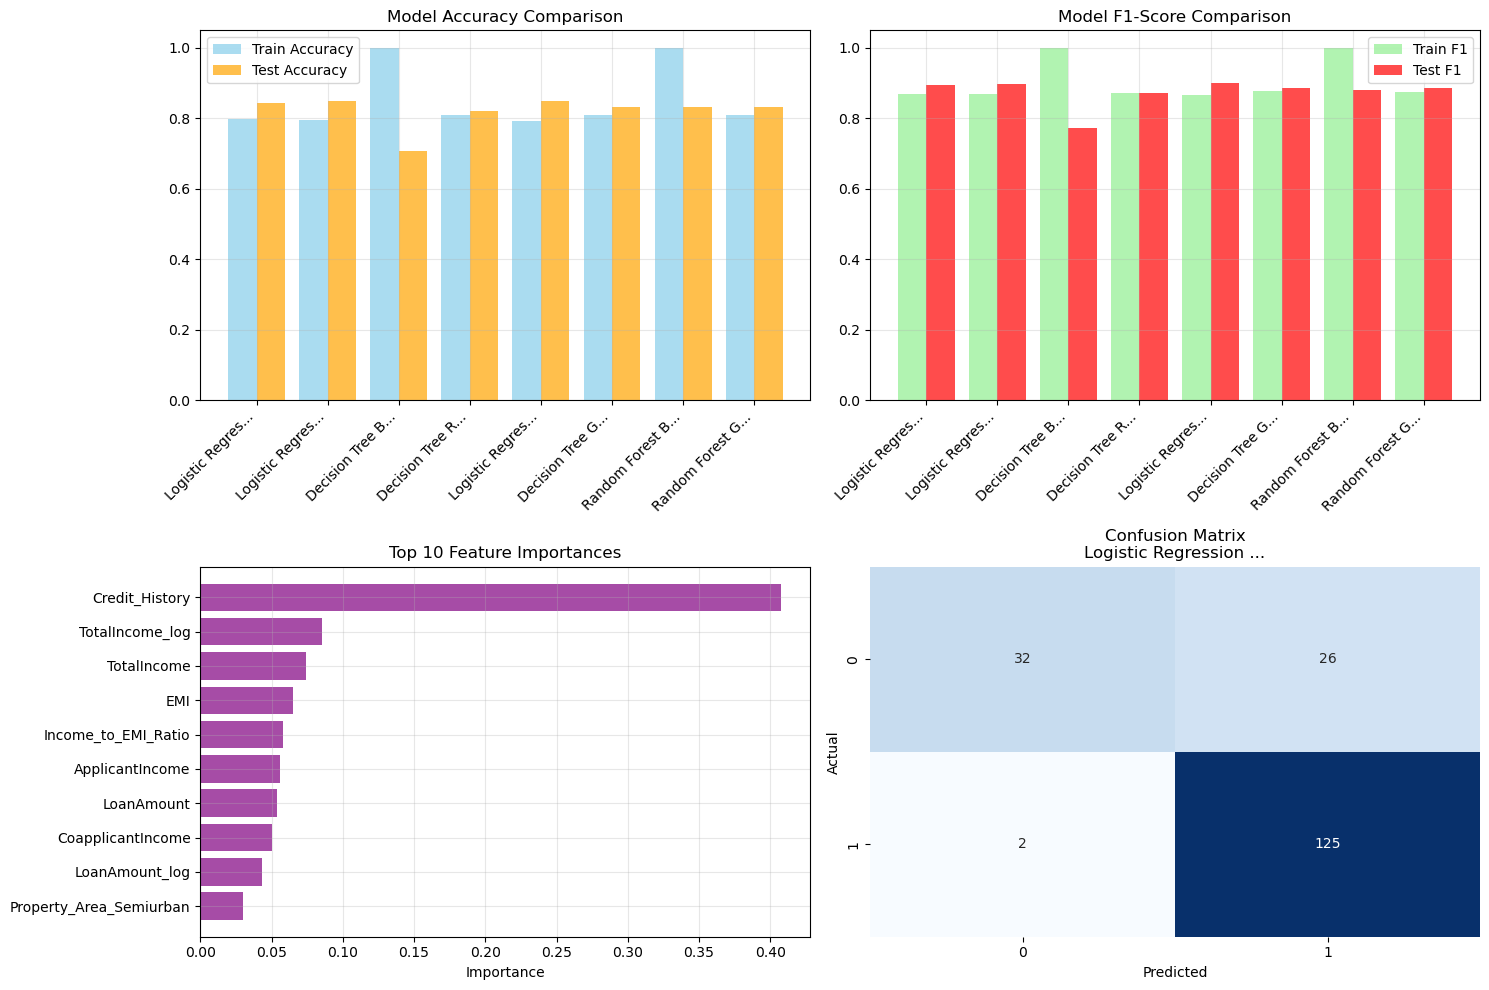

In [15]:
# FIXED: Visualization with proper prediction handling
plt.figure(figsize=(15, 10))

# Plot 1: Accuracy comparison
plt.subplot(2, 2, 1)
models = results_df['model']
train_acc = results_df['train_accuracy']
test_acc = results_df['test_accuracy']
x = range(len(models))
plt.bar(x, train_acc, width=0.4, label='Train Accuracy', alpha=0.7, color='skyblue')
plt.bar([i + 0.4 for i in x], test_acc, width=0.4, label='Test Accuracy', alpha=0.7, color='orange')
plt.xticks([i + 0.2 for i in x], [m[:15] + '...' if len(m) > 15 else m for m in models], rotation=45, ha='right')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: F1-Score comparison
plt.subplot(2, 2, 2)
train_f1 = results_df['train_f1']
test_f1 = results_df['test_f1']
plt.bar(x, train_f1, width=0.4, label='Train F1', alpha=0.7, color='lightgreen')
plt.bar([i + 0.4 for i in x], test_f1, width=0.4, label='Test F1', alpha=0.7, color='red')
plt.xticks([i + 0.2 for i in x], [m[:15] + '...' if len(m) > 15 else m for m in models], rotation=45, ha='right')
plt.title('Model F1-Score Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Feature Importance for best tree-based model
plt.subplot(2, 2, 3)
best_tree_model = None
for model_name in ['random_forest_gridsearch', 'decision_tree_gridsearch', 'random_forest_basic']:
    if model_name in all_predictions:
        if model_name == 'random_forest_gridsearch':
            best_tree_model = rf_best
        elif model_name == 'decision_tree_gridsearch':
            best_tree_model = dt_best
        elif model_name == 'random_forest_basic':
            best_tree_model = rf_basic
        break

if best_tree_model is not None and hasattr(best_tree_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_tree_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(10)
    
    plt.barh(range(len(feature_importance)), feature_importance['importance'], color='purple', alpha=0.7)
    plt.yticks(range(len(feature_importance)), feature_importance['feature'])
    plt.title('Top 10 Feature Importances')
    plt.xlabel('Importance')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'No feature importance available\nfor best tree model', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Feature Importance (Not Available)')

# Plot 4: Confusion Matrix for best model - FIXED
plt.subplot(2, 2, 4)
# Create a mapping from model display names to prediction keys
model_name_mapping = {
    'Logistic Regression L2': 'logistic_regression_l2',
    'Logistic Regression L1': 'logistic_regression_l1', 
    'Decision Tree Basic': 'decision_tree_basic',
    'Decision Tree Regularized': 'decision_tree_regularized',
    'Logistic Regression GridSearch': 'logistic_regression_gridsearch',
    'Decision Tree GridSearch': 'decision_tree_gridsearch',
    'Random Forest Basic': 'random_forest_basic',
    'Random Forest GridSearch': 'random_forest_gridsearch'
}

best_model_key = model_name_mapping.get(best_model_name)
if best_model_key and best_model_key in all_predictions:
    best_model_predictions = all_predictions[best_model_key]
    cm = confusion_matrix(y_test, best_model_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix\n{best_model_name[:20]}...' if len(best_model_name) > 20 else f'Confusion Matrix\n{best_model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
else:
    plt.text(0.5, 0.5, 'Confusion Matrix\nNot Available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

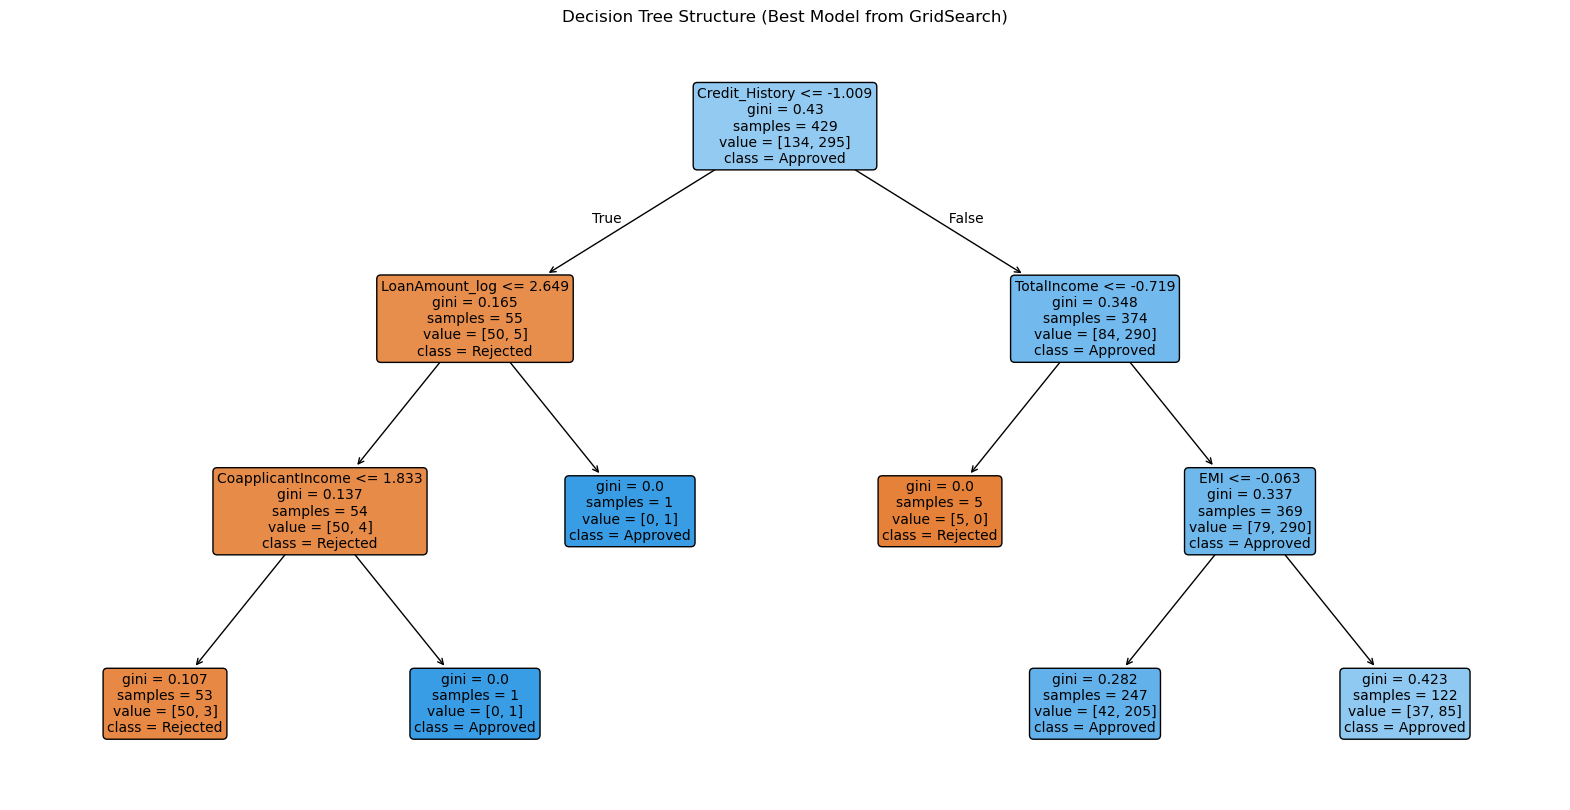

In [16]:
# Decision Tree Visualization (if available)
if dt_best is not None:
    plt.figure(figsize=(20, 10))
    plot_tree(dt_best, 
              feature_names=X.columns,
              class_names=['Rejected', 'Approved'],
              filled=True, 
              rounded=True,
              max_depth=3,  # Limit depth for readability
              fontsize=10)
    plt.title('Decision Tree Structure (Best Model from GridSearch)')
    plt.show()
else:
    print("Decision Tree visualization not available - no trained Decision Tree model found.")

In [17]:
# Detailed Model Analysis
print("\n" + "=" * 80)
print("DETAILED MODEL ANALYSIS")
print("=" * 80)

print(f"\nTotal Experiments Conducted: {len(results_df)}")
print("\nPerformance Summary:")

for idx, row in results_df.iterrows():
    print(f"\n{row['model']}:")
    print(f"  Train Accuracy: {row['train_accuracy']:.4f} | Test Accuracy: {row['test_accuracy']:.4f}")
    print(f"  Train F1: {row['train_f1']:.4f} | Test F1: {row['test_f1']:.4f}")
    overfit_gap = row['train_accuracy'] - row['test_accuracy']
    print(f"  Overfitting Gap: {overfit_gap:.4f}")

# Best model analysis
print(f"\n🎯 FINAL RECOMMENDATION:")
print(f"Best Model: {best_model_name}")
print(f"Reason: Highest Test F1-Score ({best_model['test_f1']:.4f}) with good balance between precision and recall")

print(f"\n📊 Key Insights:")
print(f"- Total experiments conducted: {len(results_df)}")
print(f"- Best test accuracy: {results_df['test_accuracy'].max():.4f}")
print(f"- Best test F1-score: {results_df['test_f1'].max():.4f}")
print(f"- Average test accuracy: {results_df['test_accuracy'].mean():.4f}")

# Model comparison
lr_models = results_df[results_df['model'].str.contains('Logistic')]
tree_models = results_df[results_df['model'].str.contains('Tree|Forest')]

print(f"\n🔍 Model Family Comparison:")
print(f"Logistic Regression (avg test F1): {lr_models['test_f1'].mean():.4f}")
print(f"Tree-based Models (avg test F1): {tree_models['test_f1'].mean():.4f}")

print(f"\n✅ MLflow Experiment Tracking:")
print(f"All experiments have been logged to MLflow")
print(f"Experiment name: 'Loan_Prediction_Experiment'")
print(f"You can view results using: mlflow ui")


DETAILED MODEL ANALYSIS

Total Experiments Conducted: 8

Performance Summary:

Logistic Regression L2:
  Train Accuracy: 0.7995 | Test Accuracy: 0.8432
  Train F1: 0.8705 | Test F1: 0.8945
  Overfitting Gap: -0.0437

Logistic Regression L1:
  Train Accuracy: 0.7949 | Test Accuracy: 0.8486
  Train F1: 0.8683 | Test F1: 0.8986
  Overfitting Gap: -0.0538

Decision Tree Basic:
  Train Accuracy: 1.0000 | Test Accuracy: 0.7081
  Train F1: 1.0000 | Test F1: 0.7731
  Overfitting Gap: 0.2919

Decision Tree Regularized:
  Train Accuracy: 0.8089 | Test Accuracy: 0.8216
  Train F1: 0.8711 | Test F1: 0.8726
  Overfitting Gap: -0.0128

Logistic Regression GridSearch:
  Train Accuracy: 0.7925 | Test Accuracy: 0.8486
  Train F1: 0.8670 | Test F1: 0.8993
  Overfitting Gap: -0.0561

Decision Tree GridSearch:
  Train Accuracy: 0.8089 | Test Accuracy: 0.8324
  Train F1: 0.8769 | Test F1: 0.8873
  Overfitting Gap: -0.0236

Random Forest Basic:
  Train Accuracy: 1.0000 | Test Accuracy: 0.8324
  Train F1: 1

In [ ]:
import subprocess
import webbrowser
import time

# Start MLflow UI in background
mlflow_process = subprocess.Popen(["mlflow", "ui", "--port", "5000"])


# Wait for server to start
time.sleep(3)

# Open browser automatically
webbrowser.open("http://localhost:5000")

print("MLflow UI started! Access at: http://localhost:5000")
print("To stop the server, run: mlflow_process.terminate()")

In [20]:
pwd

'D:\\#AIAmit\\Python\\AI\\model_experiment'

In [ ]:
!python -m mlflow ui --port 5000